In [1]:
!pip install rouge-score nltk pandas torch -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import nltk
import re
from collections import Counter
from rouge_score import rouge_scorer
import matplotlib.pyplot as plt

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Using device: {device}")

  Preparing metadata (setup.py) ... done
 Using device: cuda


In [2]:
from google.colab import files
uploaded = files.upload()  # upload clean_cnn_data.csv from data

df = pd.read_csv('clean_cnn_data.csv')

# Use 3000 sample
df = df.sample(3000, random_state=42).reset_index(drop=True)

print(f"  Loaded {len(df)} samples")
print(df.head(3))

Saving clean_cnn_data.csv to clean_cnn_data.csv
  Loaded 3000 samples
                                             article  \
0  LONDON, England A British woman who suffers fr...   
1  An A380 superjumbo bound for Sydney came loose...   
2  LAS VEGAS, Nevada A jury of nine women and thr...   

                                             summary  
0  UK court rejects appeal calling for clarificat...  
1  Four wheels of A380 superjumbo roll onto grass...  
2  NEW: Prosecutors revealed in court that no bla...  


In [7]:
# copy the preprocess.py logic here
# SAME code as local src/preprocess.py

PAD_TOKEN = '<PAD>'
SOS_TOKEN = '<SOS>'
EOS_TOKEN = '<EOS>'
UNK_TOKEN = '<UNK>'

class Vocabulary:
    def __init__(self):
        self.word2idx = {PAD_TOKEN: 0, SOS_TOKEN: 1, EOS_TOKEN: 2, UNK_TOKEN: 3}
        self.idx2word = {v: k for k, v in self.word2idx.items()}
        self.word_count = Counter()

    def build(self, texts, max_vocab_size=20000):
        for text in texts:
            tokens = nltk.word_tokenize(text.lower())
            self.word_count.update(tokens)
        most_common = self.word_count.most_common(max_vocab_size - 4)
        for word, _ in most_common:
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx] = word
        print(f"✅ Vocabulary built: {len(self.word2idx):,} words")

    def encode(self, text, max_len, add_eos=False):
    # Leave room for EOS token if needed
      actual_max = max_len - 1 if add_eos else max_len
      tokens = nltk.word_tokenize(text.lower())[:actual_max]
      ids = [self.word2idx.get(t, self.word2idx[UNK_TOKEN]) for t in tokens]

      if add_eos:
          ids = ids + [self.word2idx[EOS_TOKEN]]

    # Pad to max_len
      ids = ids + [self.word2idx[PAD_TOKEN]] * (max_len - len(ids))
      return ids

    def decode(self, ids):
        words = []
        for idx in ids:
            word = self.idx2word.get(idx, UNK_TOKEN)
            if word in [PAD_TOKEN, EOS_TOKEN, SOS_TOKEN]:
                break
            words.append(word)
        return ' '.join(words)

    def __len__(self):
        return len(self.word2idx)

def clean_text(text):
    text = text.replace('\n', ' ').strip()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\(CNN\)', '', text)
    text = re.sub(r'-- ', '', text)
    text = re.sub(r'[^a-zA-Z0-9\s\.\,\!\?\;\:\'\"-]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("  Preprocessing classes loaded")

  Preprocessing classes loaded


In [8]:
ARTICLE_MAX_LEN = 400
SUMMARY_MAX_LEN = 80

# Clean text
df['article'] = df['article'].apply(clean_text)
df['summary'] = df['summary'].apply(clean_text)

# Build vocabulary
vocab = Vocabulary()
all_texts = list(df['article']) + list(df['summary'])
vocab.build(all_texts)

# Encode
encoded_articles  = [vocab.encode(a, ARTICLE_MAX_LEN) for a in df['article']]
encoded_summaries = [vocab.encode(s, SUMMARY_MAX_LEN, add_eos=True) for s in df['summary']]

print(f"  Articles encoded  : {len(encoded_articles)} sequences of length {ARTICLE_MAX_LEN}")
print(f"  Summaries encoded : {len(encoded_summaries)} sequences of length {SUMMARY_MAX_LEN}")
print(f"  Vocab size        : {len(vocab):,}")

# Quick sanity check
print("\n--- Sanity Check ---")
print("Original :", df['article'].iloc[0][:100])
print("Encoded  :", encoded_articles[0][:10], "...")
print("Decoded  :", vocab.decode(encoded_articles[0])[:100])

✅ Vocabulary built: 20,000 words
  Articles encoded  : 3000 sequences of length 400
  Summaries encoded : 3000 sequences of length 80
  Vocab size        : 20,000

--- Sanity Check ---
Original : LONDON, England A British woman who suffers from multiple sclerosis has lost her appeal to clarify B
Encoded  : [283, 5, 405, 9, 369, 284, 43, 6671, 29, 2122] ...
Decoded  : london , england a british woman who suffers from multiple sclerosis has lost her appeal to clarify 


In [9]:
class SummarizationDataset(Dataset):
    def __init__(self, articles, summaries):
        self.articles  = torch.tensor(articles, dtype=torch.long)
        self.summaries = torch.tensor(summaries, dtype=torch.long)

    def __len__(self):
        return len(self.articles)

    def __getitem__(self, idx):
        return self.articles[idx], self.summaries[idx]

# Train / validation split — 80/20
split = int(0.8 * len(encoded_articles))

train_dataset = SummarizationDataset(encoded_articles[:split], encoded_summaries[:split])
val_dataset   = SummarizationDataset(encoded_articles[split:], encoded_summaries[split:])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)

print(f"  Train batches : {len(train_loader)}")
print(f"  Val batches   : {len(val_loader)}")

  Train batches : 75
  Val batches   : 19


In [10]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout):
        super().__init__()

        # Embedding: converts word IDs - dense vectors
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # LSTM: reads the embedded article
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        embedded = self.dropout(self.embedding(x))
        # embedded shape: (batch_size, seq_len, embed_dim)

        outputs, (hidden, cell) = self.lstm(embedded)
        # hidden shape: (num_layers, batch_size, hidden_dim)
        # cell shape:   (num_layers, batch_size, hidden_dim)

        return hidden, cell  # context vector passed to decoder

In [11]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # Final layer: hidden state → vocabulary probabilities
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, hidden, cell):
        # x shape: (batch_size) — one word at a time
        x = x.unsqueeze(1)  # → (batch_size, 1)

        embedded = self.dropout(self.embedding(x))
        # embedded shape: (batch_size, 1, embed_dim)

        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        # output shape: (batch_size, 1, hidden_dim)

        prediction = self.fc(output.squeeze(1))
        # prediction shape: (batch_size, vocab_size)

        return prediction, hidden, cell

In [13]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, vocab):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.vocab    = vocab

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        trg_len    = trg.shape[1]
        vocab_size = len(self.vocab)

        # Store decoder outputs
        outputs = torch.zeros(batch_size, trg_len, vocab_size).to(device)

        # Encode the article → context vector
        hidden, cell = self.encoder(src)

        # First decoder input is <SOS> token
        input = trg[:, 0]

        for t in range(1, trg_len):
            output, hidden, cell = self.decoder(input, hidden, cell)
            outputs[:, t, :] = output

            # Teacher forcing: sometimes use real word, sometimes predicted word
            teacher_force = torch.rand(1).item() < teacher_forcing_ratio
            input = trg[:, t] if teacher_force else output.argmax(1)

        return outputs

# Initialize model
VOCAB_SIZE  = len(vocab)
EMBED_DIM   = 256
HIDDEN_DIM  = 512
NUM_LAYERS  = 2
DROPOUT     = 0.3

encoder = Encoder(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)
decoder = Decoder(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)
model   = Seq2Seq(encoder, decoder, vocab).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Model initialized")
print(f"  Trainable parameters: {total_params:,}")

  Model initialized
  Trainable parameters: 27,856,416


In [14]:
optimizer  = optim.Adam(model.parameters(), lr=0.001)
criterion  = nn.CrossEntropyLoss(ignore_index=0)  # ignore PAD token in loss

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for articles, summaries in loader:
        articles, summaries = articles.to(device), summaries.to(device)
        optimizer.zero_grad()
        output = model(articles, summaries)
        # output: (batch, trg_len, vocab_size)
        # reshape for loss
        output = output[:, 1:, :].reshape(-1, len(vocab))
        target = summaries[:, 1:].reshape(-1)
        loss = criterion(output, target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for articles, summaries in loader:
            articles, summaries = articles.to(device), summaries.to(device)
            output = model(articles, summaries, teacher_forcing_ratio=0)
            output = output[:, 1:, :].reshape(-1, len(vocab))
            target = summaries[:, 1:].reshape(-1)
            loss = criterion(output, target)
            total_loss += loss.item()
    return total_loss / len(loader)

# Train
EPOCHS = 10
train_losses, val_losses = [], []

print("  Starting training...\n")
for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    val_loss   = eval_epoch(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

  Starting training...

Epoch 1/10 | Train Loss: 7.5389 | Val Loss: 7.1992
Epoch 2/10 | Train Loss: 7.0245 | Val Loss: 7.2241
Epoch 3/10 | Train Loss: 6.9326 | Val Loss: 7.2133
Epoch 4/10 | Train Loss: 6.8577 | Val Loss: 7.2343
Epoch 5/10 | Train Loss: 6.7918 | Val Loss: 7.2617
Epoch 6/10 | Train Loss: 6.7312 | Val Loss: 7.2649
Epoch 7/10 | Train Loss: 6.6700 | Val Loss: 7.3052
Epoch 8/10 | Train Loss: 6.6106 | Val Loss: 7.3411
Epoch 9/10 | Train Loss: 6.5614 | Val Loss: 7.3418
Epoch 10/10 | Train Loss: 6.4980 | Val Loss: 7.3502


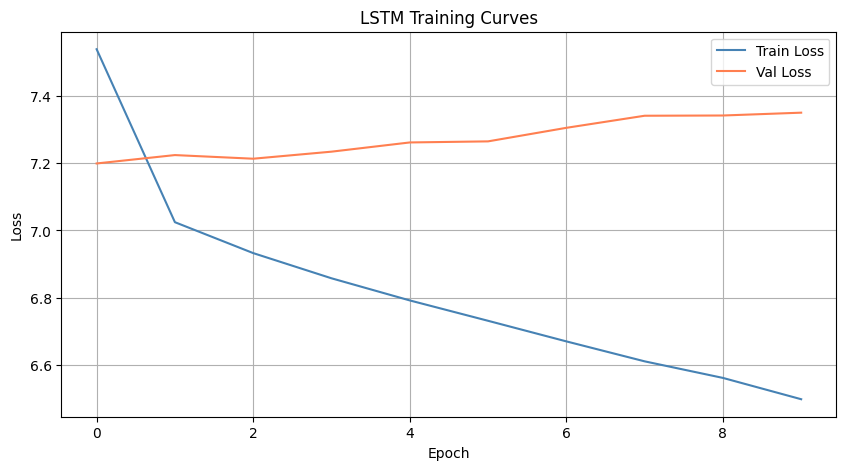

  Saved lstm_training_curves.png


In [16]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='steelblue')
plt.plot(val_losses,   label='Val Loss',   color='coral')
plt.title('LSTM Training Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('lstm_training_curves.png', dpi=150)
plt.show()
print("  Saved lstm_training_curves.png")

In [18]:
def generate_summary(model, article_text, vocab, max_len=80):
    model.eval()
    with torch.no_grad():
        encoded = vocab.encode(clean_text(article_text), ARTICLE_MAX_LEN)
        src = torch.tensor(encoded).unsqueeze(0).to(device)
        hidden, cell = model.encoder(src)

        input = torch.tensor([vocab.word2idx[SOS_TOKEN]]).to(device)
        generated = []

        for _ in range(max_len):
            output, hidden, cell = model.decoder(input, hidden, cell)
            top_token = output.argmax(1)
            word = vocab.idx2word.get(top_token.item(), UNK_TOKEN)
            if word == EOS_TOKEN:
                break
            generated.append(word)
            input = top_token

    return ' '.join(generated)

# ROUGE scores on 100 validation samples
scorer   = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
val_df   = df.iloc[split:split+100]
r1, r2, rL = [], [], []

for _, row in val_df.iterrows():
    generated = generate_summary(model, row['article'], vocab)
    reference = row['summary']
    scores    = scorer.score(reference, generated)
    r1.append(scores['rouge1'].fmeasure)
    r2.append(scores['rouge2'].fmeasure)
    rL.append(scores['rougeL'].fmeasure)

print("  ROUGE SCORES (LSTM Baseline)")
print(f"  ROUGE-1 : {sum(r1)/len(r1):.4f}")
print(f"  ROUGE-2 : {sum(r2)/len(r2):.4f}")
print(f"  ROUGE-L : {sum(rL)/len(rL):.4f}")

# Show a sample
print("\n--- Sample Output ---")
print("ARTICLE  :", val_df.iloc[0]['article'][:200])
print("REFERENCE:", val_df.iloc[0]['summary'])
print("GENERATED:", generate_summary(model, val_df.iloc[0]['article'], vocab))

  ROUGE SCORES (LSTM Baseline)
  ROUGE-1 : 0.0228
  ROUGE-2 : 0.0012
  ROUGE-L : 0.0198

--- Sample Output ---
ARTICLE  : CARACAS, Venezuela Venezuela temporarily seized a pasta-making plant Friday belonging to U.S.-based food giant Cargill, citing a production quota dispute. Venezuelan President Hugo Chavez's government
REFERENCE: Venezuela cites production quota dispute in takeover of pasta-making plant . Government will take over plant belonging to Cargill for 90 days . Minnesota-based food giant has no immediate comment on seizure . Cargill rice plant seized by President Hugo Chavez's government in March .
GENERATED: : <UNK> <UNK> , <UNK> , , , , . . . . . . . , <UNK> , , , . . . . . . . . . . . . . . . . . . . . . . .


In [19]:
import pickle

# Save model weights
torch.save(model.state_dict(), 'lstm_weights.pt')

# Save vocabulary (needed for inference later)
with open('vocab.pkl', 'wb') as f:
    pickle.dump(vocab, f)

print("  Saved lstm_weights.pt")
print("  Saved vocab.pkl")

# Download both
from google.colab import files
files.download('lstm_weights.pt')
files.download('vocab.pkl')
files.download('lstm_training_curves.png')

  Saved lstm_weights.pt
  Saved vocab.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>